In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
from anndata import AnnData
import scanpy as sc

In [2]:
# Add parent directory to path
os.chdir("/workspace/")

# Import STAGM
from src.adata_processing import (
    BatchAdataLoader,
    SingleAdataLoader
)
from src.stagm import STAGM

/opt/conda/envs/stagm-env/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/stagm-env/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [3]:
# Dataclass for the configuration of the model
@dataclass
class ModelConfig:
    seed: int
    learning_rate: float
    num_hidden: int
    num_proj_hidden: int
    activation: str
    num_layers: int
    drop_feature_rate_1: float
    drop_feature_rate_2: float
    tau: float
    num_epochs: int
    weight_decay: float
    num_clusters: int
    num_gene: int
    num_neigh: int
    k: int
    dropout: float
    order_by_degree: bool
    shuffle_ind: int
    d_state: int
    d_conv: int
    bidirectional: bool


# Dataclass for the configuration of the dataset
@dataclass
class DatasetConfig:
    dataset: str
    label: bool
    file_list: list[str]
    slide: str

In [4]:
# Initialize the model configuration with the specified parameters
model_config = ModelConfig(
    seed=39788,                # keep for your own torch/np seeding — STAGM itself doesn't read this
    learning_rate=0.0005,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    num_layers=1,               # see #1
    drop_feature_rate_1=0.1,    # see #3
    drop_feature_rate_2=0.2,    # see #3
    tau=35,                    # was 17 — see #4
    num_epochs=300,             # see #5
    weight_decay=1e-05,
    num_clusters=7,             # correct for DLPFC's 7 annotated cortical layers
    num_gene=None,              # DO NOT hardcode — see #6
    num_neigh=6,                # see #7
    k=80,                       # only meaningful if image_emb=True — see #8
    dropout=0.0,
    shuffle_ind=0,               # must stay 0 with order_by_degree=True (they're mutually exclusive)
    d_state=16,
    d_conv=4,
    order_by_degree=True,
    bidirectional=True
)


# Initialize the dataset configuration with the specified parameters
args = DatasetConfig(
    dataset="DLPFC", 
    label=True,
    file_list=['151675','151676'],
    slide='test7576'
)

In [5]:
# Define the base folder and the path to the specific dataset and slide
dataset_path = os.path.join("./Dataset", args.dataset)  # -> "./data/DLPFC"

In [6]:
loader = BatchAdataLoader(
    dataset_path=dataset_path,
    file_list=args.file_list,          # ['151675', '151676']
    n_top_genes=model_config.num_gene, # 2296 — see note #1 below
    n_neighbors=model_config.num_neigh,# BatchAdataLoader's arg is `n_neighbors`, not `num_neigh`
    image_emb=True,
    label=args.label,                  # True
    filter_na=True,
    normalize=True,                    # False if these slices are already normalized/log1p'd
)

adata = loader.run()

now load: 151675
now load: 151676
load all slices done
merged feat shape: (6997, 762)
merge done


/opt/conda/envs/stagm-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Edge probabilities: 100%|██████████| 6997/6997 [00:00<00:00, 73400.24it/s]

merge adata load done


In [7]:
model_config.num_gene = adata.obsm["feat"].shape[1]

In [8]:
# Initialize the STAGM model with the specified parameters and assign the loaded AnnData object to it
stagm = STAGM(args=args, config=model_config, single=True, refine=False)
stagm.adata = adata

In [9]:
stagm.train()

Consider intra slice
=== train ===


100%|██████████| [00:20<00:00, 14.54it/s]


In [10]:
# Evaluate the STAGM model
stagm.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     119,169
  Trainable parameters: 119,169
  Model weight size:    0.46 MB
  Peak GPU memory:      2423.22 MB
  Training time:        0m 20.6s  (20.6s total)
  Time per epoch:       68.8 ms

  Loss curve:            first=8.8503  last=8.8253  min=8.8253  max=8.8503

  Embedding shape:      (6997, 64)
  Embedding norm — mean=6.4794  std=2.2441  min=2.5384  max=12.8885

embedding generated, go clustering


In [11]:
stagm.cluster(args.label)

Searching resolution...
Cluster count 12 is too large, adjusting end downward...
Cluster count 11 is too large, adjusting end downward...
Cluster count 6 is too small, adjusting end upward...
resolution=0.1650, cluster number=11
resolution=0.1600, cluster number=11
resolution=0.1550, cluster number=11
resolution=0.1500, cluster number=10
resolution=0.1450, cluster number=10
resolution=0.1400, cluster number=9
resolution=0.1350, cluster number=7
ARI: 0.5791
resolution=0.1300, cluster number=7
ARI: 0.5908
resolution=0.1250, cluster number=7
ARI: 0.5724
resolution=0.1200, cluster number=7
ARI: 0.5955
resolution=0.1150, cluster number=7
ARI: 0.5932
resolution=0.1100, cluster number=7
ARI: 0.5932
resolution=0.1050, cluster number=7
ARI: 0.5932
resolution=0.1000, cluster number=6
resolution=0.0950, cluster number=6
resolution=0.0900, cluster number=6
resolution=0.0850, cluster number=6
resolution=0.0800, cluster number=6
resolution=0.0750, cluster number=6
resolution=0.0700, cluster number=6

start umap


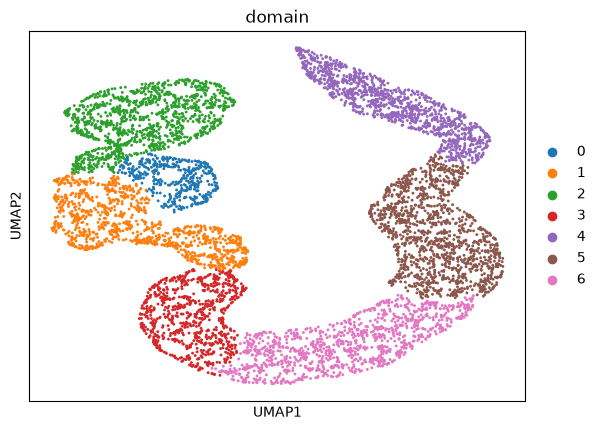

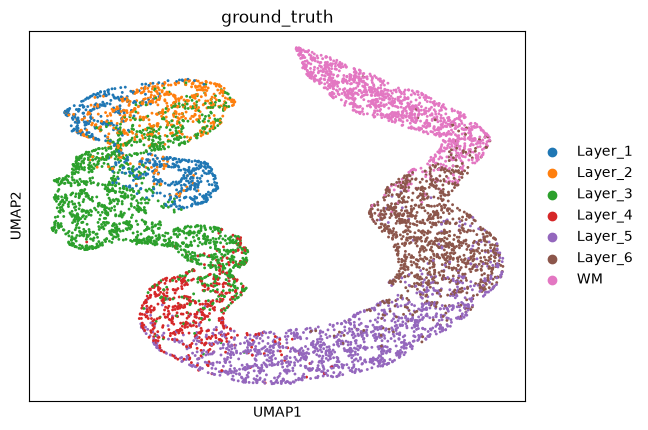

In [12]:
stagm.draw_umap()